In [7]:
import pandas as pd
import numpy as np

In [8]:
all_data = pd.read_feather(r"C:\Users\sidha\OneDrive\Desktop\Talentele\Sales_data.ftr")

In [9]:
all_data 

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,None,None,None,None,None,None
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [21]:
# Drop missing values
all_data = all_data.dropna().copy()

# Convert Qty and Price to numeric (just in case)
#all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'], errors='coerce')
#all_data['Price Each'] = pd.to_numeric(all_data['Price Each'], errors='coerce')

# Drop rows with invalid numeric values
#all_data = all_data.dropna()

# Remove negative or zero values
#all_data = all_data[(all_data['Quantity Ordered'] > 0) & (all_data['Price Each'] > 0)]


In [22]:
all_data 

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4
...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",8.97,9
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",700.00,9
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",700.00,9
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",379.99,9


In [23]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Sales', 'Month'],
      dtype='object')

In [24]:
# Check datatypes first
print(all_data[['Quantity Ordered', 'Price Each']].dtypes)

# Convert both to numeric
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'], errors='coerce')
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'], errors='coerce')

# Remove invalid rows created by coercion
all_data = all_data.dropna(subset=['Quantity Ordered', 'Price Each'])

# Convert quantity to int (optional)
all_data['Quantity Ordered'] = all_data['Quantity Ordered'].astype(int)

# Now create Sales column
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

print(all_data[['Quantity Ordered', 'Price Each', 'Sales']].head())


Quantity Ordered      int64
Price Each          float64
dtype: object
   Quantity Ordered  Price Each   Sales
0                 2       11.95   23.90
2                 1       99.99   99.99
3                 1      600.00  600.00
4                 1       11.99   11.99
5                 1       11.99   11.99


In [25]:
#Which is the best month for sale ?
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')
all_data = all_data.dropna(subset=['Order Date'])

all_data['Month'] = all_data['Order Date'].dt.month


In [26]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Sales', 'Month'],
      dtype='object')

In [27]:
all_data['Month']

0         4
2         4
3         4
4         4
5         4
         ..
186845    9
186846    9
186847    9
186848    9
186849    9
Name: Month, Length: 185950, dtype: int32

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64


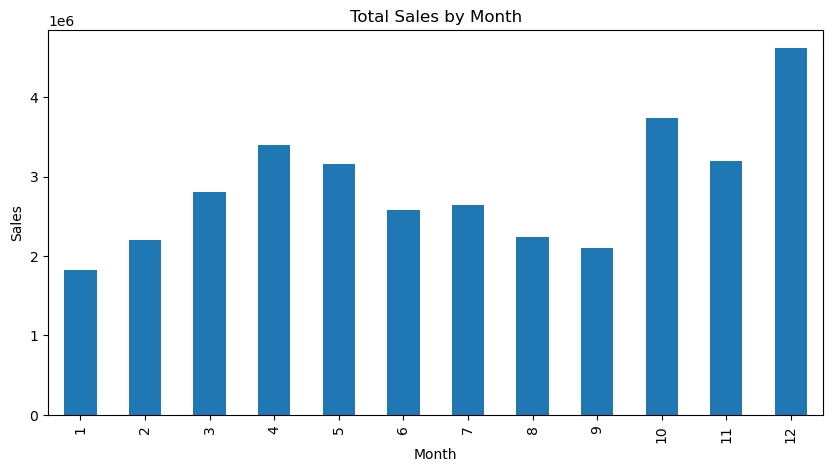

In [28]:
import matplotlib.pyplot as plt

# Convert Order Date to datetime
all_data.loc[:, 'Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')
all_data = all_data.dropna(subset=['Order Date']).copy()

# Extract month
all_data.loc[:, 'Month'] = all_data['Order Date'].dt.month

# Total Sales per month
monthly_sales = all_data.groupby('Month')['Sales'].sum()

print(monthly_sales)

# Plot column chart
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


In [30]:
month_sales_df = all_data.groupby('Month', as_index=False)['Sales'].sum()
month_sales_df = month_sales_df.sort_values('Month')

month_sales_df

,Month,Sales
0,1,1822256.73
1,2,2202022.42
2,3,2807100.38
3,4,3390670.24
4,5,3152606.75
5,6,2577802.26
6,7,2647775.76
7,8,2244467.88
8,9,2097560.13
9,10,3736726.88


In [31]:
best_month = month_sales_df.loc[month_sales_df['Sales'].idxmax()]
print("Best Month:", best_month['Month'])
print("Highest Sales:", best_month['Sales'])


Best Month: 12.0
Highest Sales: 4613443.34


In [38]:
#Analyse which city has maximum order ?
all_data["City"] = all_data["Purchase Address"].apply(lambda x: x.split(",")[1].strip())

all_data[["Purchase Address", "City"]].head()

,Purchase Address,City
0,"917 1st St, Dallas, TX 75001",Dallas
2,"682 Chestnut St, Boston, MA 02215",Boston
3,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
4,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
5,"333 8th St, Los Angeles, CA 90001",Los Angeles


In [39]:
city_orders_df = all_data.groupby("City", as_index=False)["Order ID"].count()
city_orders_df.rename(columns={"Order ID": "Total Orders"}, inplace=True)

# Add % Contribution
city_orders_df["Percent Contribution"] = (city_orders_df["Total Orders"] / city_orders_df["Total Orders"].sum()) * 100

# Sort descending
city_orders_df = city_orders_df.sort_values("Total Orders", ascending=True)

city_orders_df


,City,Total Orders,Percent Contribution
1,Austin,9905,5.326701
6,Portland,12465,6.703415
8,Seattle,14732,7.922560
3,Dallas,14820,7.969884
0,Atlanta,14881,8.002689
2,Boston,19934,10.720086
5,New York City,24876,13.377790
4,Los Angeles,29605,15.920946
7,San Francisco,44732,24.055929


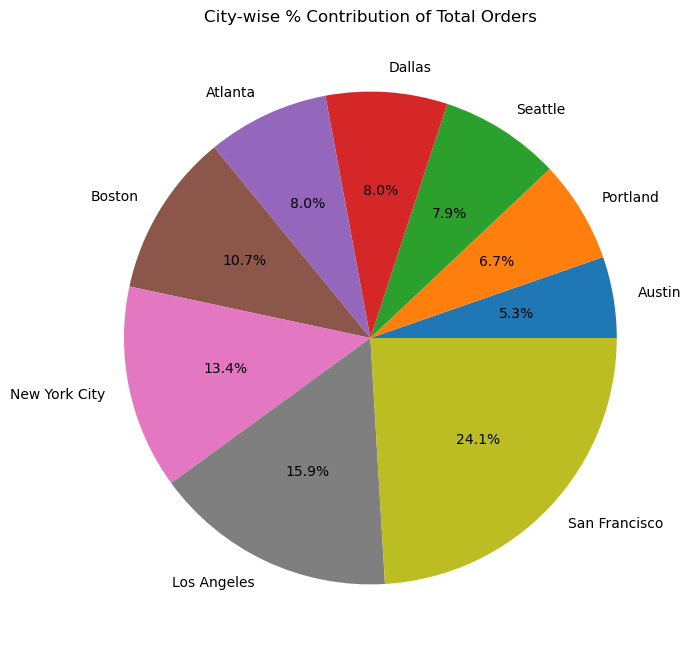

In [40]:
plt.figure(figsize=(8,8))
plt.pie(
    city_orders_df["Total Orders"],
    labels=city_orders_df["City"],
    autopct="%1.1f%%"
)
plt.title("City-wise % Contribution of Total Orders")
plt.show()

In [41]:
max_city = city_orders_df.iloc[0]
print("✅ City with Maximum Orders:", max_city["City"])
print("✅ Total Orders:", max_city["Total Orders"])
print("✅ % Contribution:", round(max_city["Percent Contribution"], 2), "%")

✅ City with Maximum Orders: Austin
✅ Total Orders: 9905
✅ % Contribution: 5.33 %


In [43]:
# understand what product sold the most and why ?
product_df = all_data.groupby('Product', as_index=False).agg(
    Qty_Sold=('Quantity Ordered', 'sum'),
    Avg_Price=('Price Each', 'mean')
)

# Sort by quantity sold (highest first)
product_df = product_df.sort_values('Qty_Sold', ascending=False)

product_df

,Product,Qty_Sold,Avg_Price
5,AAA Batteries (4-pack),31017,2.99
4,AA Batteries (4-pack),27635,3.84
15,USB-C Charging Cable,23975,11.95
12,Lightning Charging Cable,23217,14.95
17,Wired Headphones,20557,11.99
6,Apple Airpods Headphones,15661,150.00
7,Bose SoundSport Headphones,13457,99.99
2,27in FHD Monitor,7550,149.99
18,iPhone,6849,700.00
1,27in 4K Gaming Monitor,6244,389.99


In [44]:
top_product = product_df.iloc[0]
print("✅ Most Sold Product:", top_product['Product'])
print("✅ Total Qty Sold:", top_product['Qty_Sold'])
print("✅ Avg Price:", round(top_product['Avg_Price'], 2))


✅ Most Sold Product: AAA Batteries (4-pack)
✅ Total Qty Sold: 31017
✅ Avg Price: 2.99


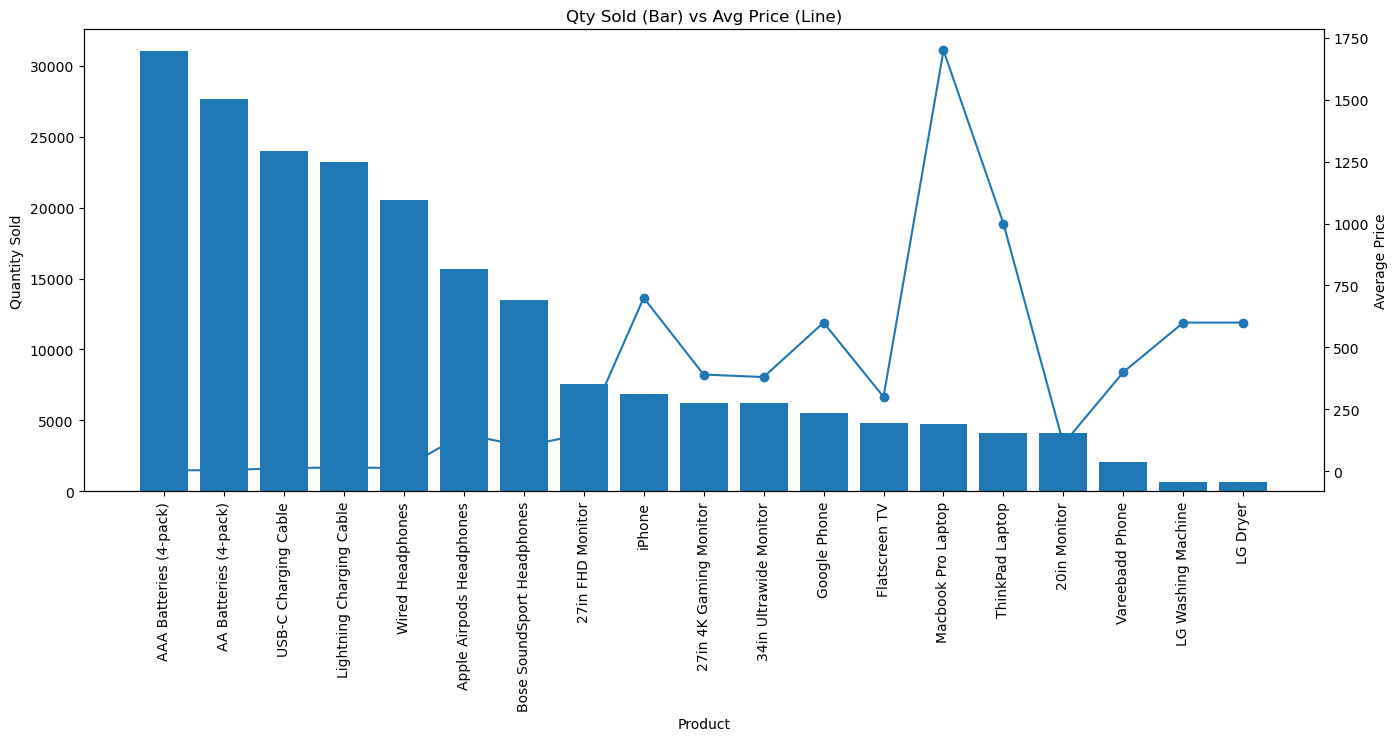

In [46]:
fig, ax1 = plt.subplots(figsize=(16,6))

# Column chart = Quantity Sold
ax1.bar(product_df['Product'], product_df['Qty_Sold'])
ax1.set_xlabel("Product")
ax1.set_ylabel("Quantity Sold")
ax1.tick_params(axis='x', rotation=90)

# Line chart = Avg Price
ax2 = ax1.twinx()
ax2.plot(product_df['Product'], product_df['Avg_Price'], marker='o')
ax2.set_ylabel("Average Price")

plt.title("Qty Sold (Bar) vs Avg Price (Line)")
plt.show()


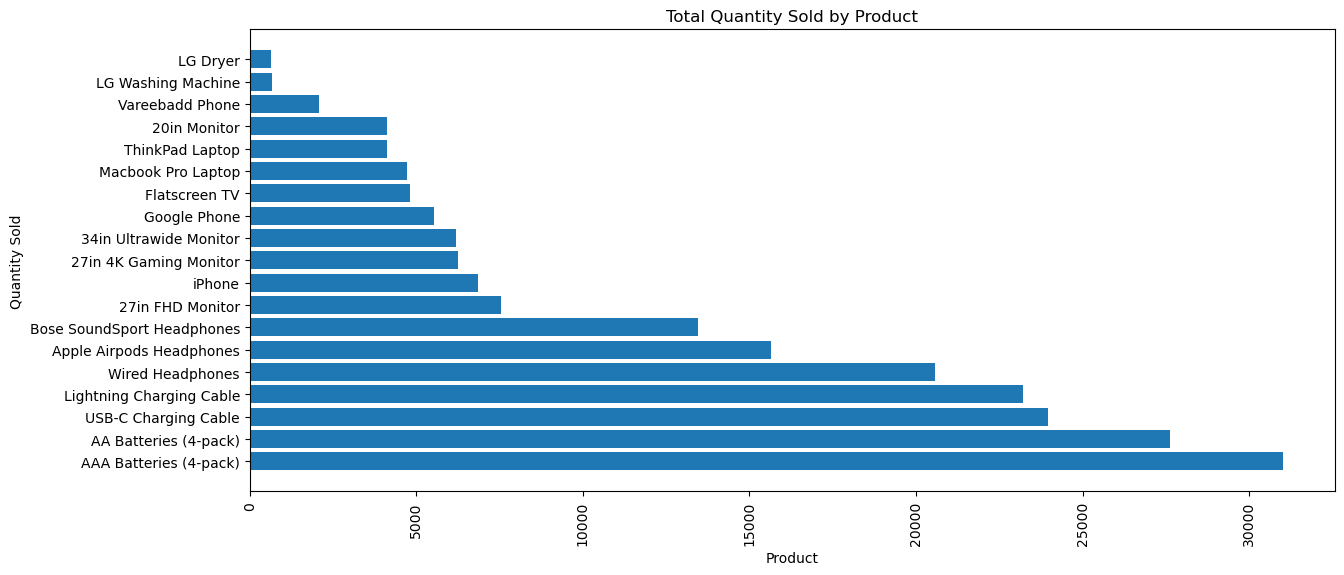

In [47]:
plt.figure(figsize=(14,6))
plt.barh(product_df['Product'], product_df['Qty_Sold'])
plt.xticks(rotation=90)
plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()


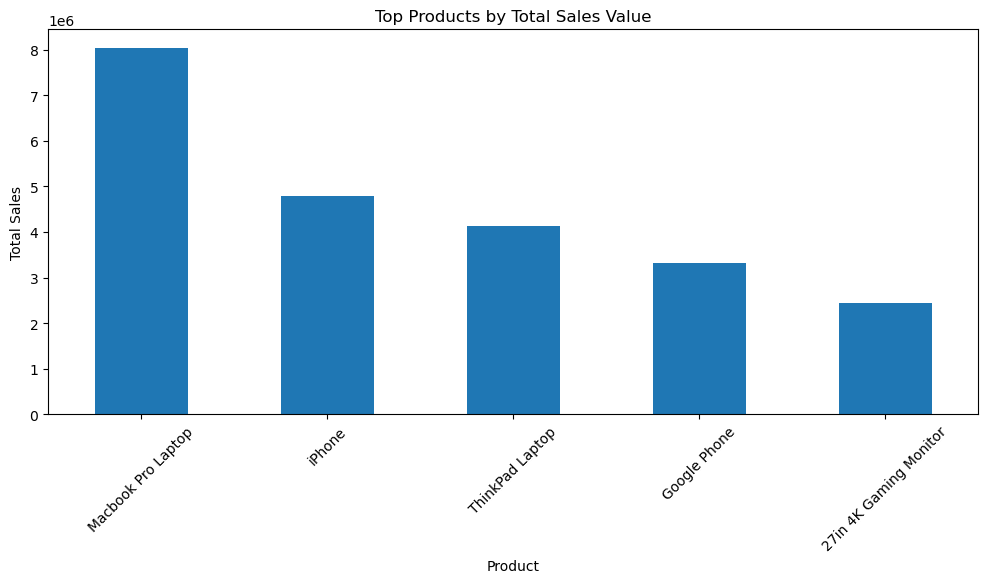

Top Products by Sales Value:
 Product
Macbook Pro Laptop        8037600.00
iPhone                    4794300.00
ThinkPad Laptop           4129958.70
Google Phone              3319200.00
27in 4K Gaming Monitor    2435097.56
Name: Sales, dtype: float64


In [50]:
top_sales = all_data.groupby("Product")["Sales"].sum().sort_values(ascending=False).head()

plt.figure(figsize=(12,5))
top_sales.plot(kind="bar")
plt.title("Top Products by Total Sales Value")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

print("Top Products by Sales Value:\n", top_sales)


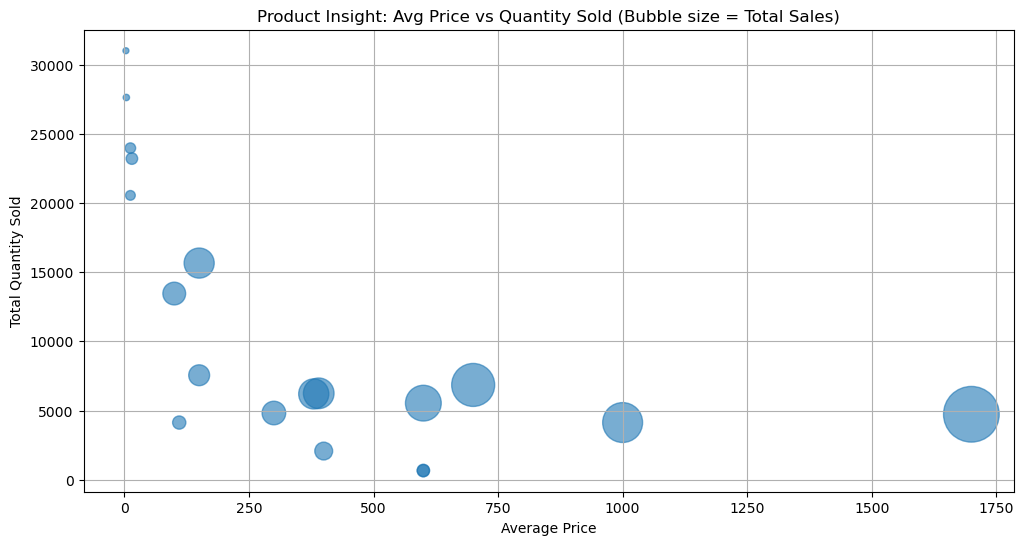

In [51]:
import matplotlib.pyplot as plt

# Product-wise Summary
product_df = all_data.groupby('Product', as_index=False).agg(
    Qty_Sold=('Quantity Ordered', 'sum'),
    Avg_Price=('Price Each', 'mean'),
    Total_Sales=('Sales', 'sum')
)

# Bubble size scaling (optional, to make bubbles visible)
bubble_size = product_df['Total_Sales'] / 5000

plt.figure(figsize=(12,6))
plt.scatter(product_df['Avg_Price'], product_df['Qty_Sold'], s=bubble_size, alpha=0.6)

plt.title("Product Insight: Avg Price vs Quantity Sold (Bubble size = Total Sales)")
plt.xlabel("Average Price")
plt.ylabel("Total Quantity Sold")
plt.grid(True)
plt.show()
